## Pré-processing et Feature Engineering

## Chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", None)

In [2]:
df_2014 = pd.read_csv(
    "../data/co2_2014.csv",
    encoding="latin1",
    sep=";"
)

df_2014.head()

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,typ_boite_nb_rapp,conso_urb,conso_exurb,conso_mixte,co2,co_typ_1,hc,nox,hcnox,ptcl,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147,M 6,"11,30000019","5,800000191","7,800000191",182.0,"0,647000015","0,052000001","0,032000002",NaN,"0,002",1505,1505,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
1,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000H341,939BXN1B53C,ES,non,12,147,M 6,"11,5",6,8,186.0,"0,647000015","0,052000001","0,032000002",NaN,"0,002",1555,1555,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100,M 6,"6,599999905","4,199999809","5,099999905",134.0,"0,066",NaN,"0,149000004","0,174999997","0,001",1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100,M 6,"6,599999905","4,199999809","5,099999905",134.0,"0,066",NaN,"0,149000004","0,174999997","0,001",1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125,M 6,"6,900000095","4,300000191","5,300000191",139.0,"0,059999999",NaN,"0,164000005","0,193000004","0,001",1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN



## État initial du dataset

In [3]:

df_2014.shape

(55044, 30)

In [4]:
df_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          55044 non-null  str    
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          55001 non-null  str    
 12  conso_exurb        55001 non-null  str    
 13  conso_mixte        55010 non-null  str    
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  str    
 16  hc                 9773 non-null 

Le jeu de données contient 55 044 observations et 30 variables.

Les variables décrivent les caractéristiques techniques des véhicules homologués en France en 2014 : marque, modèle, type de carburant, puissance, consommation, masse, norme environnementale et émissions de CO₂.

Avant toute modélisation, une phase de prétraitement est réalisée afin de nettoyer les données, traiter les valeurs manquantes et préparer le jeu de données pour les étapes suivantes. Conformément aux bonnes pratiques, les transformations apprenant des informations à partir des données (imputation, encodage ou standardisation) seront ajustées uniquement sur le jeu d'entraînement avant d'être appliquées au jeu de test, afin d'éviter tout risque de data leakage.

## Analyse des valeurs manquantes

In [5]:
(df_2014.isnull().mean() * 100).sort_values(ascending=False)

Unnamed: 27          100.000000
Unnamed: 26          100.000000
Unnamed: 29          100.000000
Unnamed: 28          100.000000
date_maj              94.101083
hc                    82.245113
hcnox                 17.963811
ptcl                   4.865199
nox                    0.287043
co_typ_1               0.287043
champ_v9               0.110820
conso_urb              0.078119
conso_exurb            0.078119
conso_mixte            0.061769
co2                    0.061769
typ_boite_nb_rapp      0.000000
puiss_admin_98         0.000000
hybride                0.000000
cod_cbr                0.000000
dscom                  0.000000
cnit                   0.000000
tvv                    0.000000
lib_mod_doss           0.000000
lib_mrq                0.000000
lib_mod                0.000000
puiss_max              0.000000
masse_ordma_max        0.000000
masse_ordma_min        0.000000
gamme                  0.000000
Carrosserie            0.000000
dtype: float64

L'analyse des valeurs manquantes met en évidence plusieurs variables fortement incomplètes.

Les colonnes `Unnamed: 26` à `Unnamed: 29` sont entièrement vides, tandis que la variable `date_maj` présente plus de 94 % de valeurs manquantes. Parmi les variables environnementales, `hc` affiche plus de 82 % de données manquantes et `hcnox` près de 18 %.

À l'inverse, la majorité des autres variables sont quasiment complètes, avec moins de 1 % de valeurs manquantes.

Ces résultats permettent d'orienter les choix de prétraitement. Les variables très fortement incomplètes seront supprimées lorsqu'elles ne présentent pas d'intérêt pour la modélisation, tandis que les variables comportant peu de valeurs manquantes feront l'objet d'un traitement adapté afin de préserver un maximum d'informations.

## Suppression des colonnes vides et peu exploitables

In [6]:
colonnes_a_supprimer = [
    'Unnamed: 26',
    'Unnamed: 27',
    'Unnamed: 28',
    'Unnamed: 29',
    'date_maj'
]

df_2014 = df_2014.drop(columns=colonnes_a_supprimer)

df_2014.shape

(55044, 25)


Les colonnes Unnamed: 26 à Unnamed: 29 ont été supprimées car elles étaient entièrement vides et n'apportaient aucune information exploitable.

La variable date_maj a également été retirée du jeu de données. Avec plus de 94 % de valeurs manquantes et sans pouvoir explicatif direct pour la prédiction des émissions de CO₂, son exploitation apparaissait peu pertinente pour la suite du projet.

Le dataset passe ainsi de 30 à 25 variables, tout en conservant les 55 044 observations initiales.

## Traitement des variables fortement incomplètes

In [7]:
df_2014 = df_2014.drop(columns=['hc', 'hcnox'])

df_2014.shape

(55044, 23)

Les variables hc et hcnox présentent respectivement plus de 82 % et près de 18 % de valeurs manquantes.

La variable hc a été supprimée en raison de son très faible niveau de complétude, rendant toute imputation peu pertinente. La variable hcnox a également été retirée afin de simplifier le jeu de données et de privilégier des variables environnementales plus complètes et directement exploitables pour la modélisation.

La variable ptcl, bien qu'incomplète, a été conservée car son taux de valeurs manquantes reste limité (moins de 5 %) et elle conserve un intérêt potentiel pour l'analyse des émissions polluantes.

Le dataset passe ainsi de 25 à 23 variables.

## Conversion des variables numériques

Certaines variables quantitatives ont été importées sous forme de chaînes de caractères en raison de l'utilisation de la virgule comme séparateur décimal. Elles sont converties au format numérique afin de permettre les calculs statistiques, les traitements de prétraitement et les futures étapes de modélisation.

In [8]:
colonnes_numeriques = [
    'puiss_max',
    'conso_urb',
    'conso_exurb',
    'conso_mixte',
    'co_typ_1',
    'nox',
    'ptcl'
]

for col in colonnes_numeriques:
    df_2014[col] = (
        df_2014[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )

    df_2014[col] = pd.to_numeric(df_2014[col], errors='coerce')

In [9]:
df_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          55044 non-null  float64
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          55001 non-null  float64
 12  conso_exurb        55001 non-null  float64
 13  conso_mixte        55010 non-null  float64
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  float64
 16  nox                54886 non-null

Les variables concernées ont été correctement converties au format numérique (float64), ce qui permettra leur utilisation dans les analyses statistiques et les algorithmes de modélisation.

Cette conversion a également permis d'identifier d'éventuelles valeurs invalides, désormais représentées sous forme de valeurs manquantes (NaN), qui seront traitées lors des étapes suivantes du prétraitement.

## Choix de la méthode d'imputation

Les variables ptcl, nox et co_typ_1 présentent un faible taux de valeurs manquantes (inférieur à 5 %). Afin de conserver l'ensemble des observations tout en limitant les biais liés aux données manquantes, plusieurs stratégies d'imputation ont été étudiées.

Une première approche consistait à réaliser une imputation par marque de véhicule. Cette solution n'a toutefois pas été retenue en raison de la forte disparité des effectifs entre les marques. Certaines sont représentées par plusieurs dizaines de milliers de véhicules, tandis que d'autres ne comptent que quelques dizaines d'observations, rendant les médianes calculées peu robustes pour les marques les moins représentées.

Une seconde approche reposait sur une imputation par type de carburant. Cette stratégie apparaît particulièrement pertinente pour certaines variables environnementales, les émissions polluantes étant directement liées à la motorisation des véhicules. Une analyse de la répartition des catégories de carburant, des effectifs associés et des médianes par carburant a donc été réalisée afin d'évaluer cette hypothèse.

Enfin, une troisième approche consistait à utiliser la médiane globale du jeu de données. Cette méthode simple et robuste permet de limiter l'influence des valeurs extrêmes tout en conservant l'ensemble des observations.

Les analyses réalisées montrent que les variables nox et co_typ_1 présentent des différences importantes selon le type de carburant, tandis que les médianes de ptcl restent très proches entre les principales catégories. En conséquence, une imputation conditionnelle par carburant a été retenue pour nox et co_typ_1, tandis qu'une imputation par la médiane globale a été privilégiée pour ptcl.

In [10]:
# Répartition des carburants
df_2014['cod_cbr'].value_counts()

cod_cbr
GO       49311
ES        5169
EH         298
GH          81
EL          34
ES/GN       32
GN/ES       32
ES/GP       23
GP/ES       23
GN          21
FE          10
EE           9
GL           1
Name: count, dtype: int64

In [11]:
# Médianes NOx par carburant
df_2014.groupby('cod_cbr')['nox'].median().sort_values()

cod_cbr
EE       0.003
EH       0.006
ES/GP    0.018
FE       0.020
GP/ES    0.026
ES       0.030
GN/ES    0.031
GN       0.032
ES/GN    0.036
GL       0.036
GH       0.061
GO       0.214
EL         NaN
Name: nox, dtype: float64

In [12]:
# Médianes PTCL par carburant
df_2014.groupby('cod_cbr')['ptcl'].median().sort_values()

cod_cbr
GL       0.000
EE       0.001
ES       0.001
EH       0.001
FE       0.001
GH       0.001
GO       0.001
GN       0.007
EL         NaN
ES/GN      NaN
ES/GP      NaN
GN/ES      NaN
GP/ES      NaN
Name: ptcl, dtype: float64

In [13]:
# Médianes CO par carburant
df_2014.groupby('cod_cbr')['co_typ_1'].median().sort_values()

cod_cbr
GL       0.020
GO       0.100
EE       0.132
EH       0.187
GH       0.222
ES       0.238
GN/ES    0.258
ES/GN    0.305
ES/GP    0.360
GN       0.370
GP/ES    0.382
FE       0.632
EL         NaN
Name: co_typ_1, dtype: float64

In [14]:
df_2014.groupby('cod_cbr')[['nox', 'co_typ_1']].count()

,nox,co_typ_1
cod_cbr,,
EE,9,9
EH,298,298
EL,0,0
ES,5096,5096
ES/GN,20,20
ES/GP,23,23
FE,10,10
GH,81,81
GL,1,1


## Analyse des résultats

L'analyse des médianes par carburant met en évidence des différences importantes pour les variables nox et co_typ_1, notamment entre les véhicules diesel (GO) et essence (ES).

Pour la variable nox, la médiane observée pour les véhicules diesel (0,214) est significativement supérieure à celle des véhicules essence (0,030). Une différence notable est également observée pour co_typ_1, avec des médianes respectives de 0,100 pour le diesel et 0,238 pour l'essence.

À l'inverse, les médianes de ptcl sont quasiment identiques quel que soit le carburant considéré, ce qui suggère une faible influence de cette variable de regroupement.

Les catégories majoritaires (GO et ES) disposent d'effectifs très élevés, garantissant la robustesse des médianes calculées. À l'inverse, certaines catégories très peu représentées (par exemple GL, FE ou EE) doivent être interprétées avec davantage de prudence. Enfin, la catégorie EL ne comporte aucune valeur disponible pour les variables nox et co_typ_1.

Ces résultats justifient le recours à une imputation conditionnelle par carburant pour les variables nox et co_typ_1, tandis qu'une imputation par la médiane globale est conservée pour ptcl.

Conformément aux bonnes pratiques de prétraitement, cette stratégie d'imputation sera appliquée uniquement après la séparation des jeux d'entraînement et de test, afin d'éviter tout risque de data leakage.

## Analyse des modalités rares

In [15]:
df_2014['lib_mrq'].value_counts(normalize=True) * 100

lib_mrq
MERCEDES        65.801904
VOLKSWAGEN      24.836494
FIAT             0.930165
BMW              0.841145
OPEL             0.724875
LEXUS            0.654022
AUDI             0.634038
FORD             0.541385
NISSAN           0.523218
CITROEN          0.399680
ALFA-ROMEO       0.332461
PEUGEOT          0.316111
RENAULT          0.290677
TOYOTA           0.254342
SKODA            0.237991
MINI             0.227091
PORSCHE          0.198023
SEAT             0.196207
VOLVO            0.196207
ASTON MARTIN     0.141705
CHEVROLET        0.138071
JEEP             0.134438
LAND ROVER       0.134438
KIA              0.121721
LANCIA           0.105370
HONDA            0.101737
SMART            0.094470
HYUNDAI          0.092653
MITSUBISHI       0.079936
MAZDA            0.074486
JAGUAR           0.070852
CADILLAC         0.069036
LAMBORGHINI      0.065402
DACIA            0.052685
SUZUKI           0.052685
BENTLEY          0.047235
FERRARI          0.045418
MASERATI         0.043601
SUBA

L'analyse de la variable lib_mrq met en évidence la présence de nombreuses modalités rares représentant moins de 0,5 % des observations. Compte tenu de l'objectif de ce premier prétraitement, aucune fusion de modalités n'a été réalisée à ce stade. Cette transformation pourra être envisagée ultérieurement si la variable est retenue pour la modélisation.

## Création de nouvelles variables

In [16]:
df_2014['rapport_puissance_masse'] = (
    df_2014['puiss_max'] /
    df_2014['masse_ordma_min']
)

In [17]:
df_2014['rapport_puissance_masse'].describe()

count    55044.000000
mean         0.057802
std          0.024929
min          0.010776
25%          0.045746
50%          0.052016
75%          0.059259
max          0.373802
Name: rapport_puissance_masse, dtype: float64

In [18]:
df_2014[['rapport_puissance_masse', 'co2']].corr()

,rapport_puissance_masse,co2
rapport_puissance_masse,1.00000,0.08878
co2,0.08878,1.00000


La corrélation linéaire observée entre cette variable et les émissions de CO₂ reste faible (0,089). Dans le cadre de cette première approche, cette variable n'apporte pas de gain explicatif suffisant et n'a donc pas été retenue pour la suite du prétraitement.

## Décision retenue

Les analyses précédentes montrent que le rapport puissance/masse présente une corrélation linéaire très faible avec les émissions de CO₂. Cette variable n'apportant pas de pouvoir explicatif supplémentaire dans cette première approche, elle est retirée du jeu de données afin de conserver un prétraitement simple et pertinent.

In [19]:
df_2014.drop(columns=['rapport_puissance_masse'], inplace=True)

## Vérification

In [20]:
'rapport_puissance_masse' in df_2014.columns

False

La faible corrélation observée avec les émissions de CO₂ (≈ 0,089) ne justifie pas le maintien de cette variable dans le jeu de données. La vérification confirme qu'elle a bien été supprimée avant les étapes de modélisation.

In [21]:
# Création du ratio puissance / masse maximale
df_2014["rapport_puissance_masse_max"] = (
    df_2014["puiss_max"] / df_2014["masse_ordma_max"]
)

In [22]:
df_2014["rapport_puissance_masse_max"].describe()

count    55044.000000
mean         0.053289
std          0.026310
min          0.010776
25%          0.040340
50%          0.046154
75%          0.057637
max          0.373802
Name: rapport_puissance_masse_max, dtype: float64

In [23]:
df_2014[["rapport_puissance_masse_max", "co2"]].corr()

,rapport_puissance_masse_max,co2
rapport_puissance_masse_max,1.000000,0.053839
co2,0.053839,1.000000


Un second ratio basé sur la masse maximale du véhicule (puiss_max / masse_ordma_max) a également été évalué. La corrélation linéaire observée avec les émissions de CO₂ (0,054) étant encore plus faible que celle obtenue avec la masse minimale, cette variable n'a pas été retenue pour la suite du prétraitement.

## Décision retenue

In [24]:
df_2014.drop(columns=["rapport_puissance_masse_max"], inplace=True)

## Vérification

In [25]:
"rapport_puissance_masse_max" in df_2014.columns

False

## Détection des valeurs aberrantes

Les valeurs aberrantes (outliers) correspondent à des observations dont les valeurs s'écartent fortement du reste de la distribution.

Leur identification est importante car elles peuvent influencer les analyses statistiques et les performances des modèles de machine learning. Dans le cas présent, l'objectif est d'identifier les éventuelles valeurs extrêmes présentes dans les principales variables quantitatives du dataset afin d'évaluer leur pertinence métier avant toute décision de traitement.

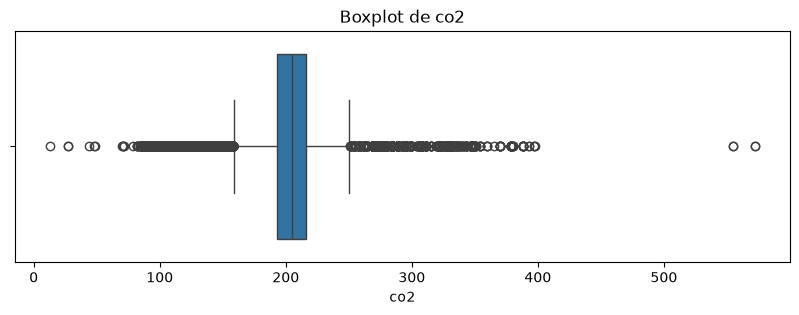

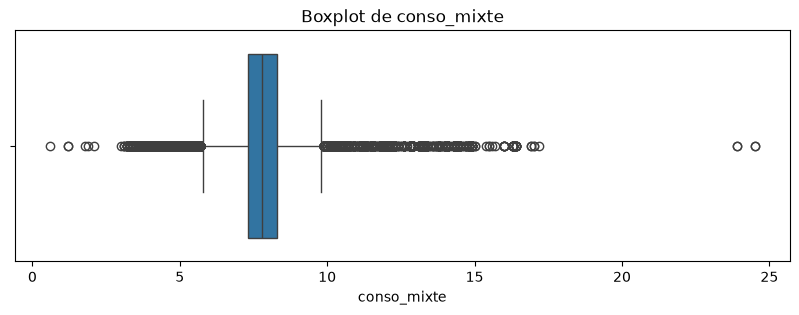

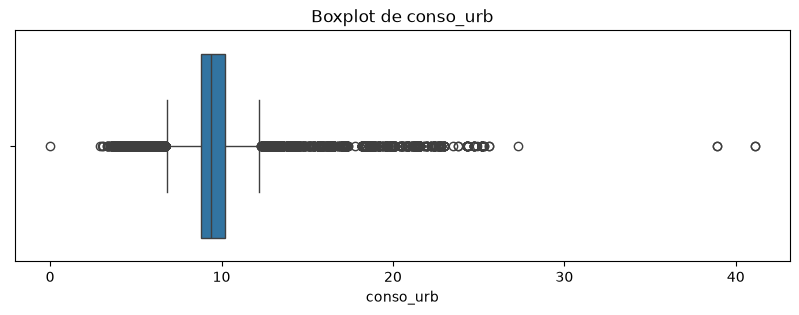

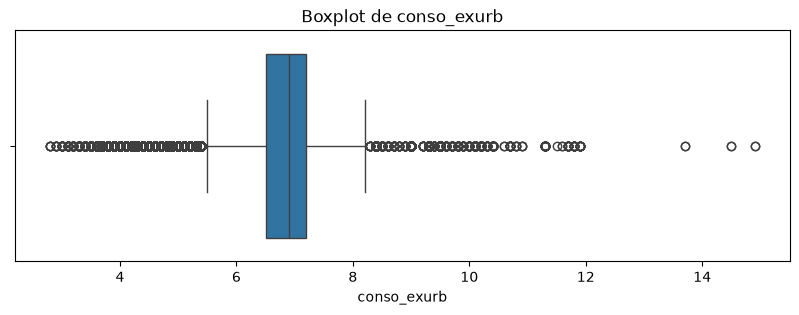

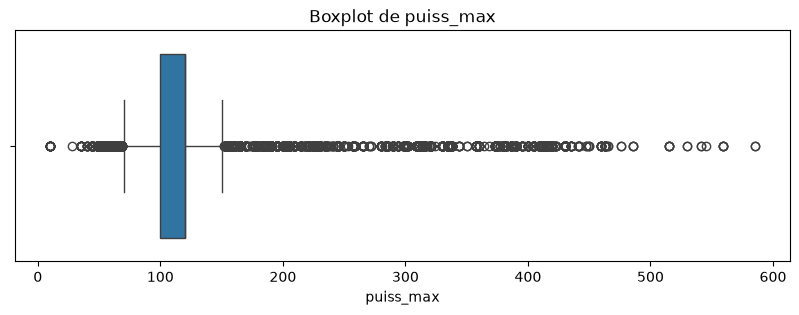

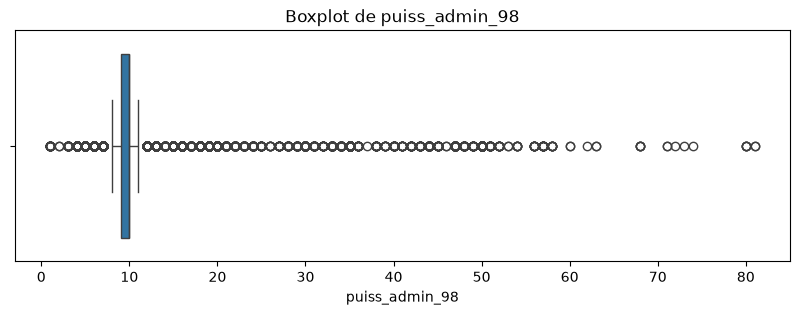

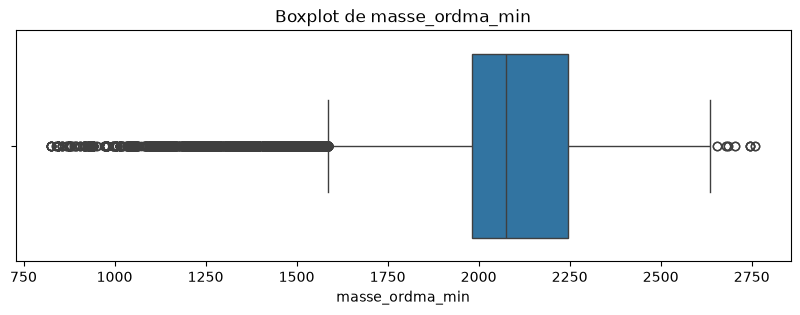

In [26]:
colonnes_numeriques = [
    'co2',
    'conso_mixte',
    'conso_urb',
    'conso_exurb',
    'puiss_max',
    'puiss_admin_98',
    'masse_ordma_min'
]

for col in colonnes_numeriques:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=df_2014[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

Les boxplots mettent en évidence la présence de valeurs extrêmes pour plusieurs variables quantitatives, notamment les émissions de CO₂, les consommations de carburant, la puissance et la masse des véhicules.

L'analyse de ces observations montre toutefois qu'elles correspondent à des véhicules réels présentant des caractéristiques techniques particulières (véhicules très puissants, très lourds ou à forte consommation). Aucune valeur incohérente ou manifestement erronée n'a été identifiée.

En conséquence, aucune suppression ni traitement spécifique des valeurs extrêmes n'a été réalisé. Ces observations ont été conservées afin de préserver la représentativité du jeu de données et la diversité des véhicules étudiés.

## Analyse des variables catégorielles

In [27]:
variables_cat = [
    'lib_mrq',
    'lib_mod_doss',
    'lib_mod',
    'dscom',
    'cnit',
    'tvv',
    'cod_cbr',
    'hybride',
    'Carrosserie',
    'gamme'
]

for col in variables_cat:
    print(f"\n{col}")
    print(df_2014[col].nunique())


lib_mrq
46

lib_mod_doss
483

lib_mod
434

dscom
3837

cnit
54982

tvv
35430

cod_cbr
13

hybride
2

Carrosserie
11

gamme
7


Une analyse du nombre de modalités a été réalisée sur les variables catégorielles du jeu de données.

Les variables cnit, tvv, dscom, lib_mod et lib_mod_doss présentent un très grand nombre de modalités et correspondent principalement à des identifiants ou références techniques propres aux véhicules. Leur encodage entraînerait une forte augmentation de la dimension du dataset sans garantie d'amélioration des performances prédictives.

À l'inverse, les variables cod_cbr, hybride, Carrosserie et gamme présentent un nombre limité de modalités et constituent des candidates pertinentes pour un encodage lors des étapes de modélisation.

## Standardisation des variables numériques

Les principales variables numériques du dataset ont été identifiées et préparées pour une future phase de modélisation. La standardisation n'a pas été appliquée à ce stade du projet car elle doit être réalisée après la séparation des jeux d'entraînement et de test afin d'éviter toute fuite d'information.

Cette transformation sera intégrée au pipeline de prétraitement lors de l'étape de modélisation pour les algorithmes qui y sont sensibles, tels que les régressions linéaires, les méthodes à noyau ou les algorithmes basés sur les distances.

# Préparation des données pour la modélisation

## Séparation de la variable cible et des variables explicatives

In [28]:
# Variable cible
y = df_2014["co2"]

# Variables explicatives
X = df_2014.drop(columns=["co2"])

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (55044, 22)
Dimensions de y : (55044,)


Avant toute étape de modélisation, le jeu de données est séparé entre les variables explicatives (X) et la variable cible (y). Cette séparation permet de distinguer les variables utilisées pour prédire les émissions de CO₂ de la variable à expliquer. Les transformations nécessitant un apprentissage des données (imputation, encodage et standardisation) seront appliquées ultérieurement, après la séparation des jeux d'entraînement et de test, afin d'éviter tout risque de data leakage.

## Séparation des jeux d'entraînement et de test

In [29]:
# Séparation du jeu de données
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test  :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test  :", y_test.shape)

Dimensions de X_train : (44035, 22)
Dimensions de X_test  : (11009, 22)
Dimensions de y_train : (44035,)
Dimensions de y_test  : (11009,)


Le jeu de données est divisé en un ensemble d'entraînement (80 %) et un ensemble de test (20 %). Conformément aux bonnes pratiques en Machine Learning, toutes les transformations nécessitant un apprentissage des données (imputation, encodage et standardisation) seront désormais ajustées uniquement sur le jeu d'entraînement, puis appliquées au jeu de test, afin d'éviter tout risque de data leakage.

## Imputation des valeurs manquantes

Les stratégies d'imputation retenues lors de l'analyse exploratoire sont désormais appliquées conformément aux bonnes pratiques du Machine Learning. Les statistiques d'imputation (médianes globales ou conditionnelles) sont calculées uniquement à partir du jeu d'entraînement (X_train), puis utilisées pour imputer les valeurs manquantes du jeu d'entraînement et du jeu de test. Cette approche permet d'éviter tout risque de data leakage.

In [30]:
# Médiane globale de PTCL calculée sur le jeu d'entraînement
ptcl_mediane = X_train["ptcl"].median()

# Médianes de NOX par type de carburant
nox_medianes = X_train.groupby("cod_cbr")["nox"].median()

# Médianes de CO_TYP_1 par type de carburant
co_typ1_medianes = X_train.groupby("cod_cbr")["co_typ_1"].median()

# Vérification des statistiques d'imputation calculées sur X_train

In [31]:
print("PTCL :", ptcl_mediane)

print("\nNOX :")
print(nox_medianes)

print("\nCO_TYP_1 :")
print(co_typ1_medianes)

PTCL : 0.001

NOX :
cod_cbr
EE       0.0055
EH       0.0060
EL          NaN
ES       0.0300
ES/GN    0.0360
ES/GP    0.0180
FE       0.0200
GH       0.0610
GL       0.0360
GN       0.0320
GN/ES    0.0310
GO       0.2140
GP/ES    0.0260
Name: nox, dtype: float64

CO_TYP_1 :
cod_cbr
EE       0.1250
EH       0.1870
EL          NaN
ES       0.2380
ES/GN    0.3050
ES/GP    0.3010
FE       0.6320
GH       0.2220
GL       0.0200
GN       0.3700
GN/ES    0.2580
GO       0.1000
GP/ES    0.3705
Name: co_typ_1, dtype: float64


### Application de l'imputation

In [32]:
# Médianes globales de secours (calculées sur le jeu d'entraînement)
nox_mediane_globale = X_train["nox"].median()
co_typ1_mediane_globale = X_train["co_typ_1"].median()

# -----------------------
# Imputation de PTCL
# -----------------------

X_train["ptcl"] = X_train["ptcl"].fillna(ptcl_mediane)
X_test["ptcl"] = X_test["ptcl"].fillna(ptcl_mediane)

# -----------------------
# Imputation de NOX
# -----------------------

X_train["nox"] = X_train["nox"].fillna(
    X_train["cod_cbr"].map(nox_medianes)
)

X_test["nox"] = X_test["nox"].fillna(
    X_test["cod_cbr"].map(nox_medianes)
)

# Cas particuliers (ex : EL)
X_train["nox"] = X_train["nox"].fillna(nox_mediane_globale)
X_test["nox"] = X_test["nox"].fillna(nox_mediane_globale)

# -----------------------
# Imputation de CO_TYP_1
# -----------------------

X_train["co_typ_1"] = X_train["co_typ_1"].fillna(
    X_train["cod_cbr"].map(co_typ1_medianes)
)

X_test["co_typ_1"] = X_test["co_typ_1"].fillna(
    X_test["cod_cbr"].map(co_typ1_medianes)
)

# Cas particuliers (ex : EL)
X_train["co_typ_1"] = X_train["co_typ_1"].fillna(co_typ1_mediane_globale)
X_test["co_typ_1"] = X_test["co_typ_1"].fillna(co_typ1_mediane_globale)

## Vérification de l'imputation

In [33]:
# Vérification des valeurs manquantes restantes
print("Valeurs manquantes dans X_train :")
print(X_train[["ptcl", "nox", "co_typ_1"]].isnull().sum())

print("\nValeurs manquantes dans X_test :")
print(X_test[["ptcl", "nox", "co_typ_1"]].isnull().sum())

Valeurs manquantes dans X_train :
ptcl        0
nox         0
co_typ_1    0
dtype: int64

Valeurs manquantes dans X_test :
ptcl        0
nox         0
co_typ_1    0
dtype: int64


L'imputation a été appliquée avec succès sur les jeux d'entraînement et de test. Aucune valeur manquante ne subsiste pour les variables ptcl, nox et co_typ_1. Les statistiques d'imputation ayant été calculées exclusivement sur le jeu d'entraînement puis appliquées au jeu de test, cette étape respecte les bonnes pratiques de prétraitement et évite tout risque de data leakage.

# Encodage des variables catégorielles

Les variables catégorielles retenues pour l'encodage ont été sélectionnées en fonction de leur nombre de modalités et de leur intérêt potentiel pour la modélisation.

Les variables présentant une très forte cardinalité (cnit, tvv, dscom, lib_mod et lib_mod_doss) n'ont pas été retenues afin d'éviter une augmentation excessive de la dimension du jeu de données. En revanche, les variables cod_cbr, hybride, Carrosserie, gamme et lib_mrq ont été conservées en raison de leur intérêt potentiel pour la prédiction des émissions de CO₂.

Conformément aux bonnes pratiques en Machine Learning, l'encodeur est ajusté uniquement sur le jeu d'entraînement (X_train), puis appliqué au jeu de test (X_test) afin d'éviter tout risque de data leakage.

In [34]:
from sklearn.preprocessing import OneHotEncoder

variables_a_encoder = [
    "cod_cbr",
    "hybride",
    "Carrosserie",
    "gamme",
    "lib_mrq"
]

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

In [35]:
# Ajustement de l'encodeur sur le jeu d'entraînement
encoder.fit(X_train[variables_a_encoder])

,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infre

In [36]:
# Transformation des variables catégorielles
X_train_encoded = encoder.transform(X_train[variables_a_encoder])
X_test_encoded = encoder.transform(X_test[variables_a_encoder])

L'encodage des variables catégorielles a été réalisé avec OneHotEncoder. L'encodeur a été ajusté exclusivement sur le jeu d'entraînement (X_train), puis appliqué au jeu de test (X_test), conformément aux bonnes pratiques visant à éviter tout risque de data leakage.

In [37]:
# Récupération des noms des variables créées
colonnes_encodees = encoder.get_feature_names_out(variables_a_encoder)

print(f"Nombre de variables créées : {len(colonnes_encodees)}")
print(colonnes_encodees)

Nombre de variables créées : 74
['cod_cbr_EH' 'cod_cbr_EL' 'cod_cbr_ES' 'cod_cbr_ES/GN' 'cod_cbr_ES/GP'
 'cod_cbr_FE' 'cod_cbr_GH' 'cod_cbr_GL' 'cod_cbr_GN' 'cod_cbr_GN/ES'
 'cod_cbr_GO' 'cod_cbr_GP/ES' 'hybride_oui' 'Carrosserie_BREAK'
 'Carrosserie_CABRIOLET' 'Carrosserie_COMBISPACE'
 'Carrosserie_COMBISPCACE' 'Carrosserie_COUPE' 'Carrosserie_MINIBUS'
 'Carrosserie_MINISPACE' 'Carrosserie_MONOSPACE'
 'Carrosserie_MONOSPACE COMPACT' 'Carrosserie_TS TERRAINS/CHEMINS'
 'gamme_INFERIEURE' 'gamme_LUXE' 'gamme_MOY-INFER' 'gamme_MOY-INFERIEURE'
 'gamme_MOY-SUPER' 'gamme_SUPERIEURE' 'lib_mrq_ASTON MARTIN'
 'lib_mrq_AUDI' 'lib_mrq_BENTLEY' 'lib_mrq_BMW' 'lib_mrq_CADILLAC'
 'lib_mrq_CHEVROLET' 'lib_mrq_CITROEN' 'lib_mrq_DACIA' 'lib_mrq_FERRARI'
 'lib_mrq_FIAT' 'lib_mrq_FORD' 'lib_mrq_HONDA' 'lib_mrq_HYUNDAI'
 'lib_mrq_INFINITI' 'lib_mrq_JAGUAR' 'lib_mrq_JEEP' 'lib_mrq_KIA'
 'lib_mrq_LADA' 'lib_mrq_LAMBORGHINI' 'lib_mrq_LANCIA'
 'lib_mrq_LAND ROVER' 'lib_mrq_LEXUS' 'lib_mrq_LOTUS' 'lib_mrq_MASE

L'encodage des variables catégorielles a été réalisé à l'aide de OneHotEncoder. Conformément aux bonnes pratiques en Machine Learning, l'encodeur a été ajusté uniquement sur le jeu d'entraînement (X_train), puis appliqué au jeu de test (X_test), ce qui permet d'éviter tout risque de data leakage.

Les variables retenues (cod_cbr, hybride, Carrosserie, gamme et lib_mrq) ont généré 74 variables indicatrices issues des cinq variables catégorielles sélectionnées. Les variables présentant une très forte cardinalité (cnit, tvv, dscom, lib_mod et lib_mod_doss) n'ont pas été encodées afin de limiter la dimension du jeu de données et de préserver l'efficacité des futurs modèles.

## Reconstruction des jeux de données

In [38]:
# Conversion des variables encodées en DataFrame
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=colonnes_encodees,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=colonnes_encodees,
    index=X_test.index
)

In [39]:
# Suppression des variables catégorielles d'origine
X_train_num = X_train.drop(columns=variables_a_encoder)

X_test_num = X_test.drop(columns=variables_a_encoder)

In [40]:
# Reconstruction des jeux de données finaux
X_train_final = pd.concat(
    [X_train_num, X_train_encoded],
    axis=1
)

X_test_final = pd.concat(
    [X_test_num, X_test_encoded],
    axis=1
)

### Vérification

In [41]:
print("Dimensions de X_train_final :", X_train_final.shape)
print("Dimensions de X_test_final  :", X_test_final.shape)

Dimensions de X_train_final : (44035, 91)
Dimensions de X_test_final  : (11009, 91)


In [42]:
X_train_final.head()

,lib_mod_doss,lib_mod,dscom,cnit,tvv,puiss_admin_98,puiss_max,typ_boite_nb_rapp,conso_urb,conso_exurb,conso_mixte,co_typ_1,nox,ptcl,masse_ordma_min,masse_ordma_max,champ_v9,cod_cbr_EH,cod_cbr_EL,cod_cbr_ES,cod_cbr_ES/GN,cod_cbr_ES/GP,cod_cbr_FE,cod_cbr_GH,cod_cbr_GL,cod_cbr_GN,cod_cbr_GN/ES,cod_cbr_GO,cod_cbr_GP/ES,hybride_oui,Carrosserie_BREAK,Carrosserie_CABRIOLET,Carrosserie_COMBISPACE,Carrosserie_COMBISPCACE,Carrosserie_COUPE,Carrosserie_MINIBUS,Carrosserie_MINISPACE,Carrosserie_MONOSPACE,Carrosserie_MONOSPACE COMPACT,Carrosserie_TS TERRAINS/CHEMINS,gamme_INFERIEURE,gamme_LUXE,gamme_MOY-INFER,gamme_MOY-INFERIEURE,gamme_MOY-SUPER,gamme_SUPERIEURE,lib_mrq_ASTON MARTIN,lib_mrq_AUDI,lib_mrq_BENTLEY,lib_mrq_BMW,lib_mrq_CADILLAC,lib_mrq_CHEVROLET,lib_mrq_CITROEN,lib_mrq_DACIA,lib_mrq_FERRARI,lib_mrq_FIAT,lib_mrq_FORD,lib_mrq_HONDA,lib_mrq_HYUNDAI,lib_mrq_INFINITI,lib_mrq_JAGUAR,lib_mrq_JEEP,lib_mrq_KIA,lib_mrq_LADA,lib_mrq_LAMBORGHINI,lib_mrq_LANCIA,lib_mrq_LAND ROVER,lib_mrq_LEXUS,lib_mrq_LOTUS,lib_mrq_MASERATI,lib_mrq_MAZDA,lib_mrq_MERCEDES,lib_mrq_MIA,lib_mrq_MINI,lib_mrq_MITSUBISHI,lib_mrq_NISSAN,lib_mrq_OPEL,lib_mrq_PEUGEOT,lib_mrq_PORSCHE,lib_mrq_RENAULT,lib_mrq_ROLLS-ROYCE,lib_mrq_SEAT,lib_mrq_SKODA,lib_mrq_SMART,lib_mrq_SSANGYONG,lib_mrq_SUBARU,lib_mrq_SUZUKI,lib_mrq_TESLA,lib_mrq_TOYOTA,lib_mrq_VOLKSWAGEN,lib_mrq_VOLVO
24348,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP608W268,639/2LAA31305N3M3D1U28,10,120.0,M 6,9.5,6.7,7.7,0.046,0.197,0.000,2186,2355,"""715/2007*692/2008EURO5",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50228,CRAFTER,CRAFTER,CRAFTER COMBI 35 L2H3 TDI (163ch) BlueMotion,M10VWGVPC47V012,2EC2KH4D1350NMEB25VA9,10,120.0,M 6,8.3,6.9,7.4,0.409,0.213,0.001,2100,2815,"""715/2007*195/2013EURO5",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
20321,VIANO,VIANO,VIANO 2.0 CDI 4x4,M10MCDVP606W331,639/2LBA73305N3A2D2W27,9,100.0,A 5,11.1,7.4,8.8,0.006,0.211,0.000,2586,2600,"""715/2007*692/2008EURO5",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41276,BEETLE,COCCINELLE,COCCINELLE CABRIOLET 1.2 TSI (105ch) DSG7,M10VWGVPA195607,16AECBZBX0FD7FD7AM006N7MJVIVR0,6,77.0,A 7,7.3,5.2,5.9,0.354,0.019,0.003,1409,1409,"""715/2007*630/2012EURO5",0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
14644,SPRINTER,SPRINTER,SPRINTER COMBI 319 CDI,M10MCDVPF17U503,906AC35KMNE1350ENEA23WB6,13,140.0,M 6,12.2,7.3,9.1,0.067,1.846,0.002,2586,2859,"""2005/55*2008/74EEV",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Les jeux de données finaux contiennent désormais les variables numériques ainsi que les variables catégorielles retenues après encodage. Certaines variables textuelles à forte cardinalité (cnit, tvv, dscom, lib_mod et lib_mod_doss) sont encore présentes et font l'objet d'une analyse complémentaire avant la préparation finale des données pour la modélisation.

## Analyse des variables textuelles à forte cardinalité

Les variables textuelles présentant un grand nombre de modalités ont fait l'objet d'une analyse spécifique afin d'évaluer leur intérêt pour la modélisation. Pour chacune d'elles, le nombre de modalités, leur fréquence et leur caractère potentiellement redondant ont été étudiés afin de déterminer si leur conservation était pertinente.

In [43]:
print("Nombre de modalités :", df_2014["cnit"].nunique())
print()

df_2014["cnit"].value_counts().head(10)

Nombre de modalités : 54982



cnit
M10ALFVP000K441    2
M10ALFVP000L442    2
M10ALFVP000P445    2
M10ALFVP000P446    2
M10CTRVP0051686    2
M10DACVP0008731    2
M10DACVP000Y624    2
M10DACVP000J609    2
M10DACVP000W622    2
M10FATVP001M592    2
Name: count, dtype: int64

La variable cnit présente 54 982 modalités pour 55 044 observations, ce qui montre qu'il s'agit d'un identifiant technique quasi unique. Son encodage générerait un très grand nombre de variables sans apporter de capacité de généralisation au modèle. Elle ne sera donc pas retenue pour la phase de modélisation.

In [44]:
print("Nombre de modalités :", df_2014["tvv"].nunique())
print()

df_2014["tvv"].value_counts().head(10)

Nombre de modalités : 35430



tvv
F142ABE                   4
F142ADE                   4
F149CDEL                  4
F149CDEB                  4
263AXG1B05                4
312PXG1AP1C               4
312PXG1AP1E               4
312PXG1AP1D               4
312PXG1AP1F               4
639/2LAA71280N1M3B2S28    4
Name: count, dtype: int64

La variable tvv présente 35 430 modalités pour 55 044 observations. Chaque modalité correspond à une référence technique très spécifique et apparaît très rarement dans le jeu de données. Son encodage entraînerait une forte augmentation de la dimension du jeu de données sans garantir une amélioration des performances prédictives. Cette variable ne sera donc pas retenue pour la modélisation.

In [45]:
print("Nombre de modalités :", df_2014["dscom"].nunique())
print()

df_2014["dscom"].value_counts().head(10)

Nombre de modalités : 3837



dscom
VIANO 2.2 CDI                  5874
VIANO 2.0 CDI                  3903
COMBI 116 CDI                  3754
COMBI 113 CDI                  2620
VIANO 3.0 CDI                  1608
SPRINTER COMBI 213 CDI - 32    1548
SPRINTER COMBI 213 CDI - 43    1258
SPRINTER COMBI 213 CDI - 37    1111
SPRINTER COMBI 316 CDI - 37    1074
VIANO 2.2 CDI 4x4               954
Name: count, dtype: int64

La variable dscom présente 3 837 modalités correspondant aux désignations commerciales des véhicules. Bien que certaines modalités soient fortement représentées, cette variable combine plusieurs informations (modèle, motorisation, version commerciale) déjà décrites par d'autres variables du jeu de données. Son encodage générerait un très grand nombre de variables et introduirait une forte redondance. Elle ne sera donc pas retenue pour la modélisation.

In [46]:
print("Nombre de modalités :", df_2014["lib_mod"].nunique())
print()

df_2014["lib_mod"].value_counts().head(10)

Nombre de modalités : 434



lib_mod
VIANO       14031
CRAFTER     13210
VITO         9890
SPRINTER     8155
E 200         468
C 180         292
C 200         258
E 220         240
E 250         228
C 220         166
Name: count, dtype: int64

La variable lib_mod présente 434 modalités correspondant aux modèles de véhicules. Bien que cette variable soit potentiellement informative, elle est fortement corrélée à la marque (lib_mrq) déjà conservée pour la modélisation. Son encodage générerait plusieurs centaines de variables supplémentaires et augmenterait la complexité du modèle sans garantir un gain significatif de performance. Elle n'a donc pas été retenue.

In [47]:
print("Nombre de modalités :", df_2014["lib_mod_doss"].nunique())
print()

df_2014["lib_mod_doss"].value_counts().head(10)

Nombre de modalités : 483



lib_mod_doss
VIANO         14031
CRAFTER       13210
VITO           9890
SPRINTER       8155
CLASSE E       1348
CLASSE C        943
CLASSE S        425
CLASSE CLS      196
CLASSE B        180
CLASSE A        176
Name: count, dtype: int64

La variable lib_mod_doss présente 483 modalités correspondant aux modèles de véhicules. Cette variable est très proche de lib_mod et apporte une information largement redondante avec la marque (lib_mrq) déjà conservée. Son encodage augmenterait fortement la dimension du jeu de données sans garantir une amélioration des performances du modèle. Elle ne sera donc pas retenue pour la modélisation.

## Conclusion générale

L'analyse des principales variables textuelles a permis d'identifier celles présentant un réel intérêt pour la modélisation. Les variables cnit, tvv, dscom, lib_mod et lib_mod_doss ont été écartées en raison de leur très forte cardinalité, de leur nature technique ou de leur redondance avec d'autres variables explicatives. À l'inverse, la variable lib_mrq, dont la cardinalité reste raisonnable et qui présente un intérêt métier, a été conservée pour l'encodage.

## Suppression des variables non retenues

In [48]:
variables_a_supprimer = [
    "cnit",
    "tvv",
    "dscom",
    "lib_mod",
    "lib_mod_doss"
]

X_train_final = X_train_final.drop(columns=variables_a_supprimer)
X_test_final = X_test_final.drop(columns=variables_a_supprimer)

print("Dimensions de X_train_final :", X_train_final.shape)
print("Dimensions de X_test_final :", X_test_final.shape)

Dimensions de X_train_final : (44035, 86)
Dimensions de X_test_final : (11009, 86)


Conformément aux conclusions de l'analyse précédente, les variables textuelles non retenues ont été supprimées des jeux d'entraînement et de test. Les jeux de données finaux sont désormais constitués uniquement de variables numériques et de variables catégorielles encodées, directement exploitables par les modèles de Machine Learning. Les étapes de prétraitement sont désormais terminées et les données sont prêtes pour la phase de modélisation.